# Analyse exploratoire des données (AED)
Dans cette section il s'agira de :
- mieux comprendre les données avec lesquelles on travaille
- la découverte de tendances, de relations et de patterns cachés dans les données
- identifier les problèmes éventuels (données manquantes, valeurs aberrantes, distributions des variables, etc.) 

Données : https://data.seattle.gov/Built-Environment/2016-Building-Energy-Benchmarking/2bpz-gwpy/about_data

In [1]:
import pandas as pd

file_path = '2016_Building_Energy_Benchmarking.csv'

df = pd.read_csv(file_path, sep=',', low_memory=False)

In [2]:
df

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57


## Comprehension et choix des features

Chaque ligne est un immeuble ou une propriété

Chaque colonne du jeu de données donne une information spécifique sur la propriété en termes d'identification, de caractéristiques physiques, d'utilisation de l'énergie, de performance énergétique et d'émissions de gaz à effet de serre, dans le cadre de la réglementation sur le benchmarking énergétique de Seattle.





---

### Identification de la propriété :
- **OSEBuildingID** : Identifiant unique attribué à chaque propriété pour le suivi et l'identification.
- **DataYear** : Année calendaire (janvier-décembre) correspondant à chaque enregistrement de données.
- **BuildingType** : Classification du type de bâtiment selon la ville de Seattle.
- **PrimaryPropertyType** : Type principal d’utilisation de la propriété (ex : bureau, magasin de détail).
- **PropertyName** : Nom officiel ou courant de la propriété dans Portfolio Manager de l'EPA.
- **Address** : Adresse de la propriété (rue).
- **City** : Ville de la propriété.
- **State** : État où se situe la propriété.
- **ZipCode** : Code postal de la propriété.
- **TaxParcelIdentificationNumber** : Numéro d'identification de la parcelle fiscale dans le comté de King.
- **CouncilDistrictCode** : District du conseil municipal de Seattle auquel appartient la propriété.
- **Neighborhood** : Quartier de la propriété défini par le département des quartiers de Seattle.
- **Latitude** : Latitude de la propriété.
- **Longitude** : Longitude de la propriété.
- **YearBuilt** : Année de construction ou de rénovation complète de la propriété.

---

### Informations sur la propriété et sa taille :
- **NumberofBuildings** : Nombre de bâtiments dans le rapport de la propriété (pour un campus, plusieurs bâtiments peuvent être inclus dans un seul rapport).
- **NumberofFloors** : Nombre d'étages du bâtiment tel que rapporté dans Portfolio Manager.
- **PropertyGFATotal** : Superficie totale brute du bâtiment, y compris les parkings.
- **PropertyGFAParking** : Surface en pieds carrés de tous les types de parkings (entièrement fermé, partiellement fermé, ouvert).
- **PropertyGFABuilding(s)** : Superficie brute du bâtiment, mesurée entre les surfaces extérieures des murs de l'enveloppe du bâtiment (comprend les espaces intérieurs, les espaces communs, les escaliers, les sous-sols, etc.).
- **ListOfAllPropertyUseTypes** : Tous les types d'utilisation de la propriété rapportés dans Portfolio Manager.
- **LargestPropertyUseType** : Le plus grand type d'utilisation de la propriété (par exemple, bureau, magasin de détail) en fonction de la superficie brute.
- **LargestPropertyUseTypeGFA** : Superficie brute du plus grand type d'utilisation de la propriété.
- **SecondLargestPropertyUseType** : Le deuxième plus grand type d'utilisation de la propriété en fonction de la superficie brute.
- **SecondLargestPropertyUseTypeGFA** : Superficie brute du deuxième type d'utilisation.
- **ThirdLargestPropertyUseType** : Le troisième plus grand type d'utilisation de la propriété.
- **ThirdLargestPropertyUseTypeGFA** : Superficie brute du troisième type d'utilisation.

---

### Certifications et performance énergétique :
- **YearsENERGYSTARCertified** : Années pendant lesquelles la propriété a reçu la certification ENERGY STAR.
- **ENERGYSTARScore** : Note ENERGY STAR, de 1 à 100, évaluant la performance énergétique globale de la propriété.
- **SiteEUI(kBtu/sf)** : Intensité d'utilisation de l'énergie sur site (EUI), mesurée en milliers de BTU par pied carré, représentant l'énergie consommée par la propriété par rapport à sa superficie.
- **SiteEUIWN(kBtu/sf)** : EUI normalisé selon les conditions météorologiques sur site, ajusté pour les conditions météorologiques moyennes sur 30 ans.
- **SourceEUI(kBtu/sf)** : Intensité de l'énergie consommée pour exploiter la propriété (y compris les pertes lors de la génération, la transmission et la distribution).
- **SourceEUIWN(kBtu/sf)** : EUI normalisé selon les conditions météorologiques de l'énergie consommée (source) par la propriété.
- **SiteEnergyUse(kBtu)** : Quantité totale d'énergie consommée sur site par la propriété, mesurée en milliers de BTU.
- **SiteEnergyUseWN(kBtu)** : Quantité d'énergie consommée ajustée selon les conditions météorologiques moyennes sur 30 ans.
- **SteamUse(kBtu)** : Quantité de vapeur de district consommée par la propriété, mesurée en milliers de BTU.
- **Electricity(kWh)** : Quantité d'électricité consommée par la propriété sur site, mesurée en kilowattheures (kWh).
- **Electricity(kBtu)** : Quantité d'électricité consommée, convertie en milliers de BTU.
- **NaturalGas(therms)** : Quantité de gaz naturel consommée par la propriété, mesurée en thermes.
- **NaturalGas(kBtu)** : Quantité de gaz naturel consommée, mesurée en milliers de BTU.

---

### Données supplémentaires et conformité :
- **DefaultData** : Indique si des données par défaut ont été utilisées pour certaines caractéristiques de la propriété.
- **Comments** : Commentaires fournis par le propriétaire ou l'agent concernant l'utilisation de l'énergie du bâtiment.
- **ComplianceStatus** : Indique si la propriété a respecté les exigences de la réglementation sur le benchmarking énergétique pour l'année de déclaration en cours.
- **Outlier** : Indique si la propriété est un cas extrême (haut ou bas) par rapport aux autres propriétés (oui/non).
- **TotalGHGEmissions** : Total des émissions de gaz à effet de serre (GES) générées par la consommation d'énergie à la propriété, mesuré en tonnes de CO2 équivalent.
- **GHGEmissionsIntensity** : Intensité des émissions de GES, calculée en kilogrammes de CO2 équivalent par pied carré de la propriété.

---

In [3]:
# Affichage des valeurs uniques dans la colonne 'BuildingType'
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Multifamily HR (10+)', 'Nonresidential WA'], dtype=object)

In [4]:
# Filtrer les lignes correspondant à des bâtiments non résidentiels
df = df[df['BuildingType'].isin([
    'NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Campus', 'Nonresidential WA'
])]

In [5]:
# La colonne complianceStatus (StatutDeConformité) permet de selectionner les propriétés ayant des données pertinentes
df = df[df['ComplianceStatus'] == 'Compliant']

In [6]:
df.shape

(1548, 46)

In [7]:
df.iloc[:, 39:46]

,NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...
3370,2.997200e+05,False,NaN,Compliant,NaN,20.33,1.11
3372,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57


In [8]:
# Liste des colonnes à supprimer
colonnes_a_supprimer = [
    'DataYear','PropertyName', 'Address', 'ZipCode', 'City', 'State', 
    'ZipCode', 'CouncilDistrictCode', 'TaxParcelIdentificationNumber', 
    'Latitude', 'Longitude', 'DefaultData', 'Comments', 
    'ComplianceStatus', 'Outlier'
]

# La colonne Outlier ne contient que des valeurs nulles

# Suppression des colonnes
df1 = df.drop(columns=colonnes_a_supprimer)

In [9]:
df1 = df1.drop(columns=["BuildingType","SiteEUI(kBtu/sf)" , "SiteEUIWN(kBtu/sf)", "SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)", "SiteEnergyUse(kBtu)", "Electricity(kWh)", "NaturalGas(therms)"])
df1.shape

(1548, 24)

In [10]:
df = df1.drop(columns=['YearsENERGYSTARCertified'])
df.shape

(1548, 23)

In [11]:
df.iloc[:, 1:13]

,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType
0,Hotel,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN
1,Hotel,DOWNTOWN,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking
2,Hotel,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN
3,Hotel,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN
4,Hotel,DOWNTOWN,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking
...,...,...,...,...,...,...,...,...,...,...,...,...
3370,Other,DELRIDGE NEIGHBORHOODS,1982,1.0,1,18261,0,18261,Other - Recreation,Other - Recreation,18261.0,NaN
3372,Other,DOWNTOWN,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN
3373,Other,MAGNOLIA / QUEEN ANNE,1974,1.0,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583.0,Fitness Center/Health Club/Gym
3374,Mixed Use Property,GREATER DUWAMISH,1989,1.0,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601.0,Fitness Center/Health Club/Gym


In [12]:
missing_data = df.isnull().sum()
missing_data[missing_data > 0]

LargestPropertyUseType                4
LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseType        706
SecondLargestPropertyUseTypeGFA     706
ThirdLargestPropertyUseType        1200
ThirdLargestPropertyUseTypeGFA     1200
ENERGYSTARScore                     551
SiteEnergyUseWN(kBtu)                 1
dtype: int64

In [13]:
# Y a-t-il des lignes en double ? 
df.duplicated().sum()

0

In [14]:
# Suppression des lignes ayant des NaN
df = df.dropna(subset=['LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SiteEnergyUseWN(kBtu)'])
df.shape

(1543, 23)

In [15]:
# La colonne NumberofBuildings est de type float alors qu'il n'y a pas de nombre de batiment à virgule.
# Je convertis le type en int
df['NumberofBuildings'] = df['NumberofBuildings'].astype(int)
df['NumberofFloors'] = df['NumberofFloors'].astype(int)

## Outliers & Valeurs manquantes

### Outliers de la colonne NumberOfBuildings

In [16]:
import matplotlib.pyplot as plt

def showRepartitionVarCategorielle(colonne_categorielle) :
    # Charger les données (remplace avec ton DataFrame réel)
    building_type_counts = df[colonne_categorielle].value_counts()

    # Créer le graphique en barres pour plus de lisibilité
    plt.figure(figsize=(10, 6))
    building_type_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title(f'Répartition colonne {colonne_categorielle}')
    plt.xlabel('Type de Propriété')
    plt.ylabel('Nombre d\'Occurrences')
    plt.xticks(rotation=45, ha='right')
    plt.show()

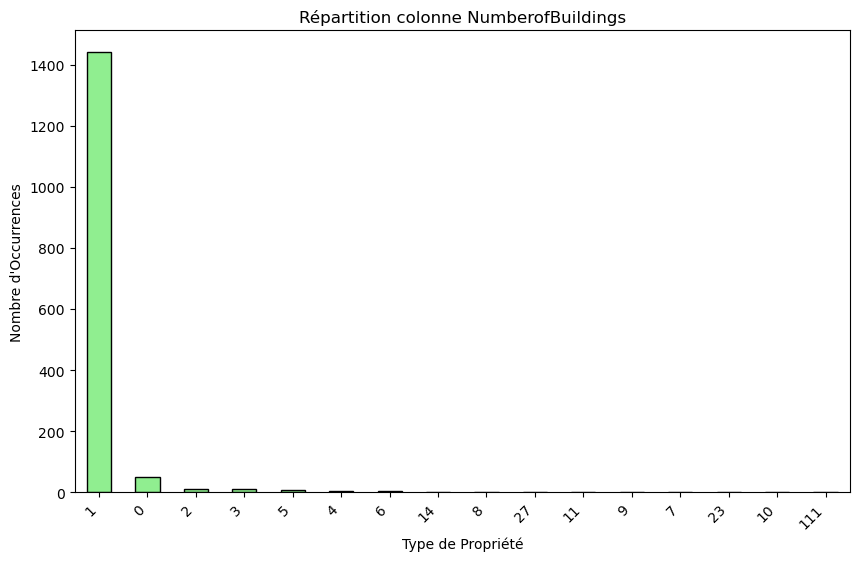

In [17]:
showRepartitionVarCategorielle('NumberofBuildings')

In [18]:
print(len(df[df['NumberofBuildings'] == 0]), "lignes")
df[df['NumberofBuildings'] == 0]

52 lignes


,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,...,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
63,89,Medical Office,EAST,1965,0,3,179014,0,179014,Medical Office,...,NaN,NaN,NaN,48.0,1.652771e+07,0.000000e+00,9886484.0,6814570.0,430.84,2.41
76,113,Small- and Mid-Sized Office,MAGNOLIA / QUEEN ANNE,1986,0,2,66240,2352,63888,"Data Center, Distribution Center, Office, Park...",...,5181.0,Distribution Center,4551.0,NaN,4.192108e+06,0.000000e+00,4166305.0,0.0,29.04,0.44
160,257,Warehouse,GREATER DUWAMISH,1916,0,4,79600,0,79600,Non-Refrigerated Warehouse,...,NaN,NaN,NaN,34.0,2.411402e+06,0.000000e+00,2411402.0,0.0,16.81,0.21
201,322,Large Office,DOWNTOWN,1968,0,3,100734,26731,74003,Office,...,NaN,NaN,NaN,20.0,9.892566e+06,0.000000e+00,9788716.0,0.0,68.24,0.68
241,366,Small- and Mid-Sized Office,NORTHEAST,1961,0,5,99005,0,99005,Office,...,NaN,NaN,NaN,70.0,5.008124e+06,0.000000e+00,2863212.0,1865277.0,119.03,1.20
264,391,Mixed Use Property,GREATER DUWAMISH,1970,0,1,88400,0,88400,"Distribution Center, Non-Refrigerated Warehous...",...,29620.0,Distribution Center,27715.0,42.0,4.811200e+06,0.000000e+00,2530658.0,1852442.0,116.03,1.31
278,408,Large Office,DOWNTOWN,1926,0,10,132326,0,132326,"Office, Other, Retail Store",...,12610.0,Retail Store,9835.0,72.0,6.146692e+06,3.282471e+05,5698221.0,2551.0,65.20,0.49
280,410,Hotel,DOWNTOWN,1973,0,19,332067,59280,272787,Hotel,...,NaN,NaN,NaN,6.0,3.798415e+07,1.558601e+07,19800542.0,2398995.0,1468.50,4.42
291,421,Other,DOWNTOWN,1996,0,4,267335,166960,100375,"Movie Theater, Other - Restaurant/Bar, Parking",...,69947.0,Other - Restaurant/Bar,27400.0,NaN,7.378420e+06,0.000000e+00,5169902.0,2103253.0,147.75,0.55
358,504,Other,DELRIDGE,1955,0,1,113780,0,113780,"Office, Other - Services",...,22248.0,NaN,NaN,NaN,4.021869e+06,0.000000e+00,1470885.0,2103657.0,121.98,1.07


In [19]:
# Filtrer les lignes où 'NumberofBuildings' est égal à 0
filtered_rows = df[df['NumberofBuildings'] == 0]

# Compter le nombre d'éléments séparés par une virgule dans la colonne 'ListOfAllPropertyUseTypes'
df.loc[filtered_rows.index, 'NumberofBuildings'] = filtered_rows['ListOfAllPropertyUseTypes'].apply(lambda x: len(x.split(',')))

In [20]:
df.loc[filtered_rows.index]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,...,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
63,89,Medical Office,EAST,1965,1,3,179014,0,179014,Medical Office,...,NaN,NaN,NaN,48.0,1.652771e+07,0.000000e+00,9886484.0,6814570.0,430.84,2.41
76,113,Small- and Mid-Sized Office,MAGNOLIA / QUEEN ANNE,1986,5,2,66240,2352,63888,"Data Center, Distribution Center, Office, Park...",...,5181.0,Distribution Center,4551.0,NaN,4.192108e+06,0.000000e+00,4166305.0,0.0,29.04,0.44
160,257,Warehouse,GREATER DUWAMISH,1916,1,4,79600,0,79600,Non-Refrigerated Warehouse,...,NaN,NaN,NaN,34.0,2.411402e+06,0.000000e+00,2411402.0,0.0,16.81,0.21
201,322,Large Office,DOWNTOWN,1968,1,3,100734,26731,74003,Office,...,NaN,NaN,NaN,20.0,9.892566e+06,0.000000e+00,9788716.0,0.0,68.24,0.68
241,366,Small- and Mid-Sized Office,NORTHEAST,1961,1,5,99005,0,99005,Office,...,NaN,NaN,NaN,70.0,5.008124e+06,0.000000e+00,2863212.0,1865277.0,119.03,1.20
264,391,Mixed Use Property,GREATER DUWAMISH,1970,3,1,88400,0,88400,"Distribution Center, Non-Refrigerated Warehous...",...,29620.0,Distribution Center,27715.0,42.0,4.811200e+06,0.000000e+00,2530658.0,1852442.0,116.03,1.31
278,408,Large Office,DOWNTOWN,1926,3,10,132326,0,132326,"Office, Other, Retail Store",...,12610.0,Retail Store,9835.0,72.0,6.146692e+06,3.282471e+05,5698221.0,2551.0,65.20,0.49
280,410,Hotel,DOWNTOWN,1973,1,19,332067,59280,272787,Hotel,...,NaN,NaN,NaN,6.0,3.798415e+07,1.558601e+07,19800542.0,2398995.0,1468.50,4.42
291,421,Other,DOWNTOWN,1996,3,4,267335,166960,100375,"Movie Theater, Other - Restaurant/Bar, Parking",...,69947.0,Other - Restaurant/Bar,27400.0,NaN,7.378420e+06,0.000000e+00,5169902.0,2103253.0,147.75,0.55
358,504,Other,DELRIDGE,1955,2,1,113780,0,113780,"Office, Other - Services",...,22248.0,NaN,NaN,NaN,4.021869e+06,0.000000e+00,1470885.0,2103657.0,121.98,1.07


In [21]:
# Suppression des colonnes inutiles
df = df.drop(columns=['LargestPropertyUseType','SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', "ListOfAllPropertyUseTypes"])
df.shape

(1543, 17)

### Outliers de la colonne NumberofFloors

<Axes: xlabel='NumberofFloors'>

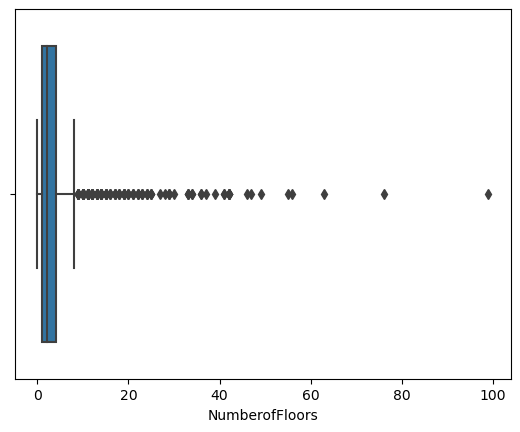

In [22]:
import seaborn as sns

sns.boxplot(data=df, x='NumberofFloors')

In [23]:
df.describe()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1543.000000,1543.000000,1543.000000,1543.000000,1.543000e+03,1543.000000,1.543000e+03,1.543000e+03,994.000000,1.543000e+03,1.543000e+03,1.543000e+03,1.543000e+03,1543.000000,1543.000000
mean,16503.683085,1961.677900,1.254051,4.274789,1.214780e+05,13830.705120,1.076473e+05,9.993248e+04,63.595573,8.455270e+06,5.529691e+05,6.151676e+06,2.041684e+06,194.002191,1.669929
std,13834.062495,32.864014,3.053183,6.790333,3.067720e+05,43747.147997,2.930837e+05,2.855935e+05,28.832632,2.280459e+07,5.727680e+06,2.154456e+07,9.726059e+06,780.330309,2.410969
min,1.000000,1900.000000,1.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,1.000000,0.000000e+00,0.000000e+00,-1.154170e+05,0.000000e+00,-0.800000,-0.020000
25%,602.500000,1930.000000,1.000000,1.000000,2.884250e+04,0.000000,2.792050e+04,2.501050e+04,44.000000,1.322090e+06,0.000000e+00,7.304495e+05,0.000000e+00,20.550000,0.360000
50%,21181.000000,1966.000000,1.000000,2.000000,4.811200e+04,0.000000,4.606800e+04,4.195800e+04,71.000000,2.811924e+06,0.000000e+00,1.738749e+06,4.860440e+05,49.900000,0.880000
75%,24603.500000,1989.000000,1.000000,4.000000,1.072160e+05,0.000000,9.571050e+04,9.200300e+04,88.000000,7.509929e+06,0.000000e+00,5.267771e+06,1.530936e+06,147.315000,1.970000
max,50226.000000,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,100.000000,4.716139e+08,1.349435e+08,6.570744e+08,2.979090e+08,16870.980000,34.090000


In [24]:
print(len(df[(df['NumberofFloors'] == 0)]))
df[(df['NumberofFloors'] == 0)]

16


,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
166,267,Hotel,DOWNTOWN,1999,1,0,934292,0,934292,495536.0,NaN,66502836.0,0.0,39364114.0,25683162.0,1638.46,1.75
487,656,Medical Office,EAST,2004,1,0,225982,0,225982,200184.0,53.0,20764814.0,7815663.0,12744957.0,0.0,692.12,3.06
488,657,Mixed Use Property,DOWNTOWN,2006,7,0,516407,0,516407,385196.0,31.0,40754364.0,0.0,29432803.0,9970512.0,734.72,1.42
564,758,Other,DOWNTOWN,1999,1,0,947987,0,947987,561684.0,NaN,46343304.0,0.0,46510954.0,0.0,324.25,0.34
1754,23311,Medical Office,EAST,1945,1,0,274568,0,274568,228133.0,52.0,25358122.0,13296249.0,12015275.0,0.0,1110.07,4.04
1993,24086,Other,GREATER DUWAMISH,1991,10,0,230971,0,230971,230970.0,NaN,22230844.0,0.0,15419770.0,5602515.0,405.05,1.75
3130,40028,Warehouse,NORTHEAST,1940,1,0,384772,0,384772,349953.0,69.0,16139557.0,0.0,9014872.0,6191888.0,391.70,1.02
3131,40031,Medical Office,NORTHEAST,1960,1,0,30287,0,30287,28050.0,32.0,2279632.5,0.0,1815405.0,377710.0,32.72,1.08
3132,40034,Small- and Mid-Sized Office,NORTHEAST,1960,1,0,21931,0,21931,31845.0,32.0,4292216.0,0.0,1398591.0,2548619.0,145.11,6.62
3168,49705,Other,NORTHEAST,1929,8,0,502030,0,502030,564258.0,NaN,20672948.0,0.0,9359884.0,9110455.0,549.11,1.09


In [25]:
import numpy as np
# remplacer par Nan dans la colonne NumberOfFloor, les propriétés ayant numberOfFloor à 0
df.loc[df['NumberofFloors'] == 0, 'NumberofFloors'] = np.nan

In [26]:
len(df[df['NumberofFloors'].isna()])

16

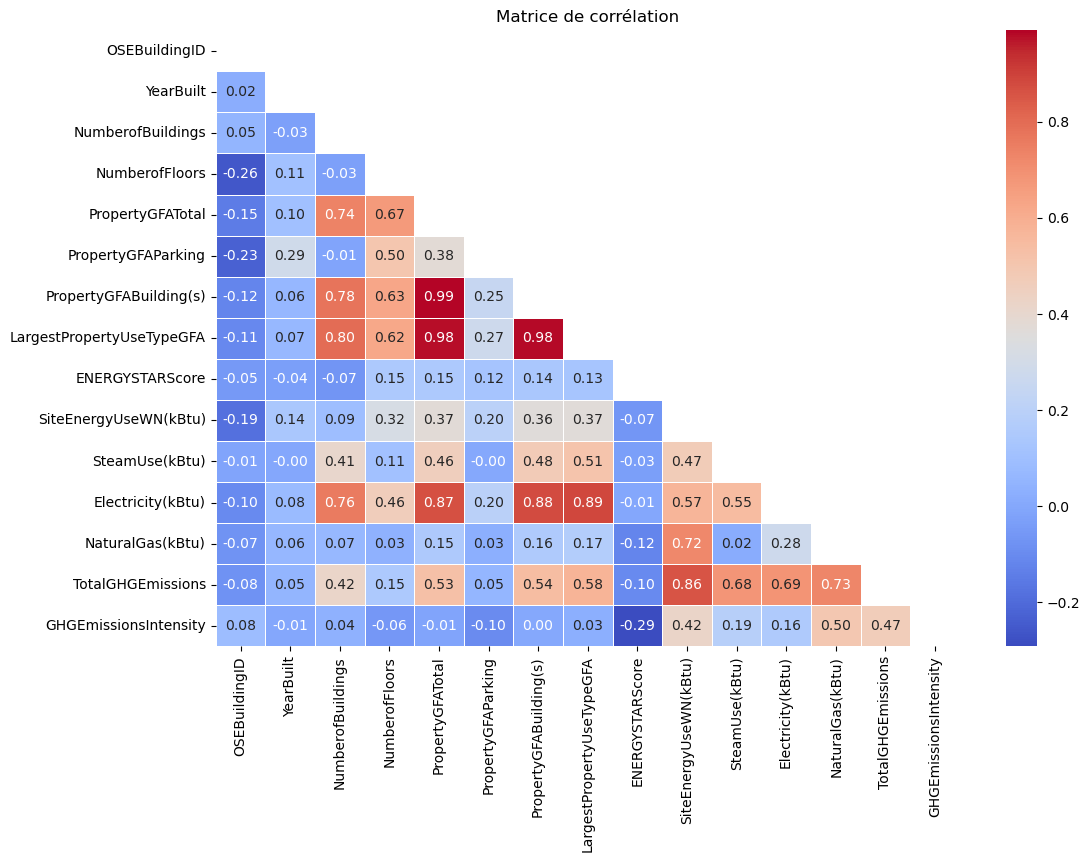

In [27]:
def correlation() :
    # Garder uniquement les colonnes numériques
    numeric_columns = df.select_dtypes(include=['float64', 'int64', 'int32', 'float32']).columns
    
    # Calculer la matrice de corrélation
    correlation_matrix = df[numeric_columns].corr()
    
    # Masquer la moitié de la matrice (triangulaire supérieure)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    # Afficher la heatmap optimisée
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matrice de corrélation")
    plt.show()
correlation()

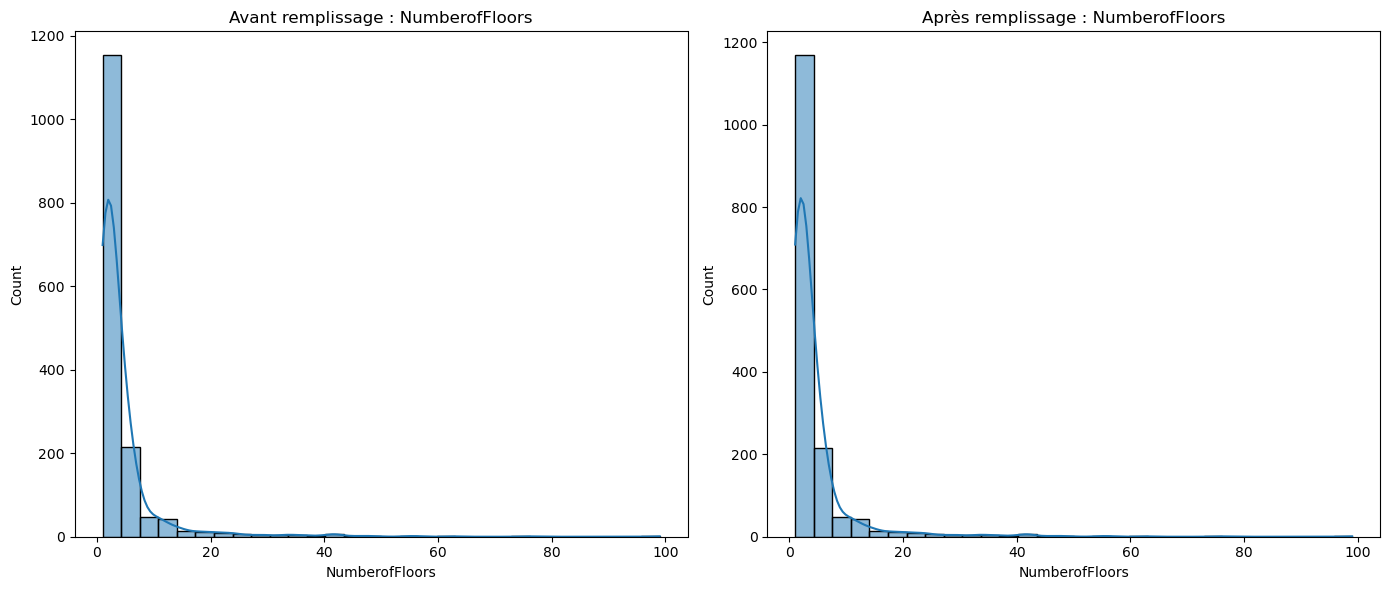

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supposons que la fonction 'replace_nan_by_mediane' est définie comme suit :
def replace_nan_by_mediane(df, group_col, target_col):
    # Remplir les valeurs manquantes de target_col avec la médiane du groupe défini par group_col
    median_values = df.groupby(group_col)[target_col].median()
    df[target_col] = df.apply(
        lambda row: median_values[row[group_col]] if pd.isna(row[target_col]) else row[target_col], 
        axis=1
    )
    return df

# Liste des colonnes à traiter
columns_to_fill = ["NumberofFloors"]

# Affichage avant remplissage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution avant remplissage
sns.histplot(df["NumberofFloors"], kde=True, ax=axes[0], bins=30)
axes[0].set_title("Avant remplissage : NumberofFloors")
axes[0].set_xlabel("NumberofFloors")

# Remplir les valeurs manquantes
for col in columns_to_fill:
    df = replace_nan_by_mediane(df, "PrimaryPropertyType", col)

# Distribution après remplissage
sns.histplot(df["NumberofFloors"], kde=True, ax=axes[1],  bins=30)
axes[1].set_title("Après remplissage : NumberofFloors")
axes[1].set_xlabel("NumberofFloors")

plt.tight_layout()
plt.show()

In [29]:
df.describe()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1543.000000,1543.000000,1543.000000,1543.000000,1.543000e+03,1543.000000,1.543000e+03,1.543000e+03,994.000000,1.543000e+03,1.543000e+03,1.543000e+03,1.543000e+03,1543.000000,1543.000000
mean,16503.683085,1961.677900,1.254051,4.303305,1.214780e+05,13830.705120,1.076473e+05,9.993248e+04,63.595573,8.455270e+06,5.529691e+05,6.151676e+06,2.041684e+06,194.002191,1.669929
std,13834.062495,32.864014,3.053183,6.779272,3.067720e+05,43747.147997,2.930837e+05,2.855935e+05,28.832632,2.280459e+07,5.727680e+06,2.154456e+07,9.726059e+06,780.330309,2.410969
min,1.000000,1900.000000,1.000000,1.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,1.000000,0.000000e+00,0.000000e+00,-1.154170e+05,0.000000e+00,-0.800000,-0.020000
25%,602.500000,1930.000000,1.000000,1.000000,2.884250e+04,0.000000,2.792050e+04,2.501050e+04,44.000000,1.322090e+06,0.000000e+00,7.304495e+05,0.000000e+00,20.550000,0.360000
50%,21181.000000,1966.000000,1.000000,2.000000,4.811200e+04,0.000000,4.606800e+04,4.195800e+04,71.000000,2.811924e+06,0.000000e+00,1.738749e+06,4.860440e+05,49.900000,0.880000
75%,24603.500000,1989.000000,1.000000,4.000000,1.072160e+05,0.000000,9.571050e+04,9.200300e+04,88.000000,7.509929e+06,0.000000e+00,5.267771e+06,1.530936e+06,147.315000,1.970000
max,50226.000000,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,100.000000,4.716139e+08,1.349435e+08,6.570744e+08,2.979090e+08,16870.980000,34.090000


### Outlier au niveau des colonnes Electricity(kBtu) et GHGEmissionsIntensity
Ces colonnes contiennent des colonnes négatives et probablement nulles. Je vais les identifier et les traiter.

<Axes: xlabel='Electricity(kBtu)'>

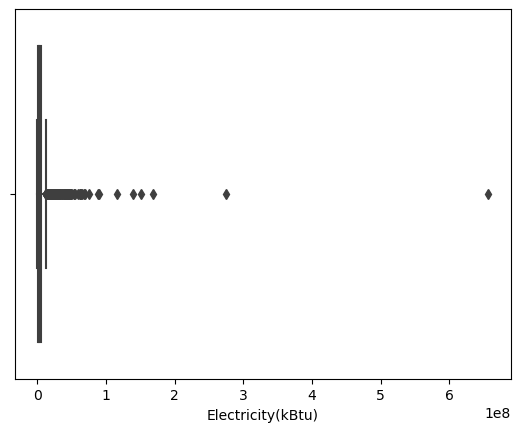

In [30]:
sns.boxplot(data=df, x='Electricity(kBtu)')

In [31]:
len(df[df['Electricity(kBtu)'] >= 4e+08])

1

In [32]:
df = df[df['Electricity(kBtu)'] <= 4e+08]

<Axes: xlabel='Electricity(kBtu)'>

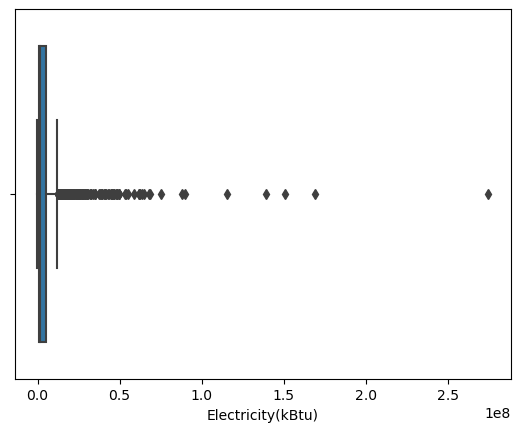

In [33]:
sns.boxplot(data=df, x='Electricity(kBtu)')

In [34]:
df[df["Electricity(kBtu)"] <= 1000]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
426,23854,Restaurant,DOWNTOWN,1900,1,1.0,43728,0,43728,43728.0,NaN,1.185445e+07,0.0,0.0,11508035.0,611.19,13.98
513,700,Supermarket / Grocery Store,MAGNOLIA / QUEEN ANNE,2008,1,1.0,57176,0,57176,39500.0,31.0,1.284386e+07,0.0,0.0,0.0,0.00,0.00
1670,23064,Other,NORTHWEST,1970,5,1.0,23166,0,23166,23166.0,NaN,3.648466e+06,0.0,3.0,3475801.0,184.60,7.97
3206,49784,Small- and Mid-Sized Office,CENTRAL,2013,1,6.0,52000,0,52000,48159.0,100.0,2.401321e+05,0.0,-115417.0,0.0,-0.80,-0.02


In [35]:
# Remplacer les valeurs de Electricity(kBtu) <= 1000 par NaN
# Car ce n'est pas normal de voir des propriété consommé moins de 1000
df.loc[df["Electricity(kBtu)"] <= 1000, "Electricity(kBtu)"] = np.nan

<Axes: xlabel='GHGEmissionsIntensity'>

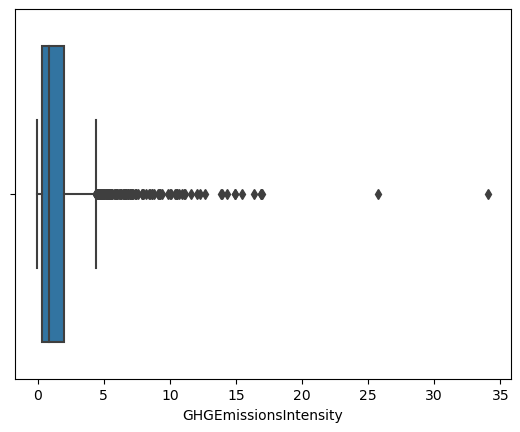

In [36]:
sns.boxplot(data=df, x='GHGEmissionsIntensity')

In [37]:
df[df["GHGEmissionsIntensity"] <= 0]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
513,700,Supermarket / Grocery Store,MAGNOLIA / QUEEN ANNE,2008,1,1.0,57176,0,57176,39500.0,31.0,1.284386e+07,0.0,NaN,0.0,0.0,0.00
3206,49784,Small- and Mid-Sized Office,CENTRAL,2013,1,6.0,52000,0,52000,48159.0,100.0,2.401321e+05,0.0,NaN,0.0,-0.8,-0.02


In [38]:
df.loc[df["GHGEmissionsIntensity"] <= 0, "GHGEmissionsIntensity"] = np.nan

In [39]:
# Liste des colonnes à traiter
columns_to_fill = ["GHGEmissionsIntensity","Electricity(kBtu)"]

# Remplir les valeurs manquantes
for col in columns_to_fill:
    df = replace_nan_by_mediane(df, "PrimaryPropertyType", col)

### Outlier SiteEnergyUseWN(kBtu)

In [40]:
df.describe()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1542.000000,1542.000000,1542.000000,1542.000000,1.542000e+03,1542.000000,1.542000e+03,1.542000e+03,994.000000,1.542000e+03,1.542000e+03,1.542000e+03,1.542000e+03,1542.000000,1542.000000
mean,16481.981842,1961.717899,1.182879,4.304799,1.155126e+05,13839.674449,1.016730e+05,9.395309e+04,63.595573,8.460754e+06,4.982141e+05,5.737511e+06,2.043008e+06,186.903256,1.673862
std,13812.253254,32.837083,1.227637,6.781217,1.980528e+05,43759.920863,1.756225e+05,1.625229e+05,28.832632,2.281097e+07,5.310227e+06,1.375798e+07,9.729075e+06,729.040998,2.412635
min,1.000000,1900.000000,1.000000,1.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,1.000000,0.000000e+00,0.000000e+00,6.138000e+03,0.000000e+00,-0.800000,0.010000
25%,602.250000,1930.000000,1.000000,1.000000,2.884175e+04,0.000000,2.791425e+04,2.500525e+04,44.000000,1.322536e+06,0.000000e+00,7.398290e+05,0.000000e+00,20.505000,0.360000
50%,21180.500000,1966.000000,1.000000,2.000000,4.806600e+04,0.000000,4.606350e+04,4.194000e+04,71.000000,2.818011e+06,0.000000e+00,1.748792e+06,4.881350e+05,49.845000,0.885000
75%,24602.750000,1989.000000,1.000000,4.000000,1.066552e+05,0.000000,9.530650e+04,9.198375e+04,88.000000,7.523219e+06,0.000000e+00,5.268490e+06,1.531061e+06,147.105000,1.980000
max,50226.000000,2015.000000,27.000000,99.000000,2.200000e+06,512608.000000,2.200000e+06,1.719643e+06,100.000000,4.716139e+08,1.349435e+08,2.745325e+08,2.979090e+08,16870.980000,34.090000


<Axes: xlabel='SiteEnergyUseWN(kBtu)'>

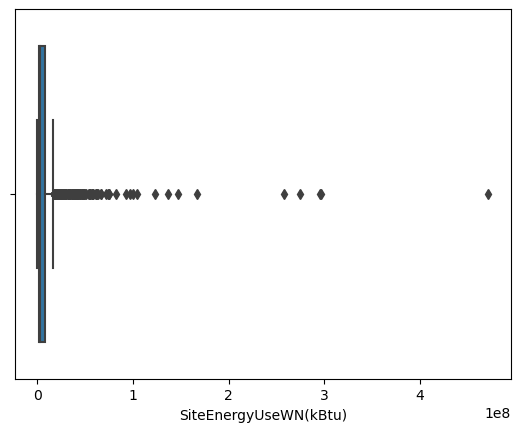

In [41]:
sns.boxplot(data=df, x='SiteEnergyUseWN(kBtu)')

In [42]:
len(df[df['SiteEnergyUseWN(kBtu)'] >= 0.70e+08])

18

In [43]:
# J'ai décidé de retirer les valeurs trop extreme (il s'agissait de  4 lignes)
df = df[df['SiteEnergyUseWN(kBtu)'] <= 0.70e+08]

<Axes: xlabel='SiteEnergyUseWN(kBtu)'>

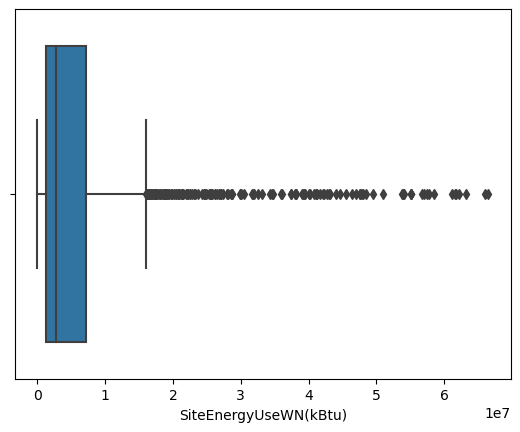

In [44]:
sns.boxplot(data=df, x='SiteEnergyUseWN(kBtu)')

In [45]:
df[df["SiteEnergyUseWN(kBtu)"] <= 0]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
220,343,Large Office,DOWNTOWN,1958,1,17.0,378525,84600,293925,236827.0,69.0,0.0,10921066.00,13985064.0,0.0,940.47,2.48
247,372,Large Office,DOWNTOWN,1988,1,20.0,497513,118744,378769,367623.0,65.0,0.0,0.00,26602310.0,220905.0,197.19,0.40
284,414,Large Office,DOWNTOWN,1929,1,15.0,151039,0,151039,125473.0,84.0,0.0,2850077.75,2596546.0,0.0,238.09,1.58
350,493,Small- and Mid-Sized Office,MAGNOLIA / QUEEN ANNE,1971,1,5.0,88000,21600,66400,69691.0,75.0,0.0,0.00,3484915.0,0.0,24.29,0.28
882,20130,Worship Facility,Northwest,1910,1,2.0,23931,0,23931,23931.0,88.0,0.0,0.00,167075.0,329402.0,18.66,0.78
953,20324,Worship Facility,NORTHEAST,2000,1,2.0,31386,0,31386,30000.0,52.0,0.0,0.00,710478.0,417701.0,27.14,0.86
3275,49968,University,NORTHEAST,1969,1,4.0,58779,0,58779,58779.0,NaN,0.0,0.00,3719217.0,0.0,25.93,0.44
3277,49972,University,NORTHEAST,1998,1,6.0,203030,0,203030,203030.0,NaN,0.0,0.00,28614613.0,0.0,199.48,0.98


In [46]:
df.loc[df["SiteEnergyUseWN(kBtu)"] <= 0, "SiteEnergyUseWN(kBtu)"] = np.nan
# Liste des colonnes à traiter
columns_to_fill = ["SiteEnergyUseWN(kBtu)"]

# Remplir les valeurs manquantes
for col in columns_to_fill:
    df = replace_nan_by_mediane(df, "PrimaryPropertyType", col)

In [47]:
df.describe()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1524.000000,1524.000000,1524.000000,1524.000000,1.524000e+03,1524.000000,1.524000e+03,1.524000e+03,979.000000,1.524000e+03,1.524000e+03,1.524000e+03,1.524000e+03,1524.000000,1524.000000
mean,16579.173228,1961.618110,1.154856,4.159449,1.063156e+05,13386.839895,9.292878e+04,8.497861e+04,63.700715,6.662323e+06,2.643005e+05,4.734720e+06,1.493005e+06,132.645820,1.609938
std,13782.247667,32.894704,1.136008,6.330380,1.692898e+05,42650.922005,1.452478e+05,1.312911e+05,28.811554,1.005833e+07,1.706720e+06,8.007932e+06,3.133174e+06,237.989664,2.199342
min,1.000000,1900.000000,1.000000,1.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,1.000000,5.811420e+04,0.000000e+00,6.138000e+03,0.000000e+00,-0.800000,0.010000
25%,606.750000,1930.000000,1.000000,1.000000,2.880000e+04,0.000000,2.779700e+04,2.497975e+04,44.000000,1.325357e+06,0.000000e+00,7.295642e+05,0.000000e+00,20.165000,0.357500
50%,21200.000000,1965.000000,1.000000,2.000000,4.755700e+04,0.000000,4.563700e+04,4.157050e+04,71.000000,2.803276e+06,0.000000e+00,1.686214e+06,4.752735e+05,49.365000,0.880000
75%,24625.250000,1989.000000,1.000000,4.000000,1.029475e+05,0.000000,9.343650e+04,8.908900e+04,88.000000,7.272668e+06,0.000000e+00,5.012304e+06,1.476731e+06,139.067500,1.950000
max,50226.000000,2015.000000,27.000000,99.000000,1.605578e+06,512608.000000,1.592914e+06,1.585960e+06,100.000000,6.650284e+07,3.103019e+07,6.382214e+07,3.468533e+07,2573.750000,25.710000


### Outlier : Propriété où le largestProperty est supérieur au TotalProperty

In [48]:
df[df['LargestPropertyUseTypeGFA'] > df['PropertyGFATotal']]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
11,16,Hotel,DOWNTOWN,1998,1,25.0,333176,61161,272015,336640.0,36.0,2.707011e+07,5999360.5,18083049.0,2858700.0,740.97,2.22
43,56,Hotel,DOWNTOWN,1969,1,24.0,332210,205970,126240,348630.0,67.0,1.616319e+07,0.0,12204406.0,3958787.0,295.33,0.89
59,84,Senior Care Community,SOUTHWEST,1922,1,5.0,217603,0,217603,296313.0,54.0,4.554725e+07,0.0,11824772.0,30967300.0,1727.11,7.94
66,98,Retail Store,LAKE UNION,1929,1,2.0,58320,0,58320,72072.0,96.0,1.243028e+06,0.0,361803.0,687945.0,39.06,0.67
72,107,Large Office,LAKE UNION,2010,1,12.0,571329,0,571329,598801.0,91.0,4.015343e+07,0.0,32206199.0,7399685.0,617.52,1.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3294,50002,Other,NORTHEAST,2014,1,3.0,33648,0,33648,83600.0,NaN,1.399582e+06,0.0,1399582.0,0.0,9.76,0.29
3319,50035,Hotel,DOWNTOWN,2015,1,14.0,144614,0,144614,159500.0,89.0,5.547964e+06,0.0,5269208.0,255864.0,50.32,0.35
3322,50039,Other,GREATER DUWAMISH,2015,1,2.0,108036,0,108036,202171.0,NaN,5.298718e+06,0.0,3752536.0,1239357.0,91.98,0.85
3347,50081,K-12 School,GREATER DUWAMISH,2015,1,3.0,45000,0,45000,45728.0,77.0,1.397742e+06,0.0,1325973.0,0.0,9.24,0.21


In [49]:
indexeOutliers = df[df['LargestPropertyUseTypeGFA'] > df['PropertyGFATotal']].index

In [50]:
# Remplacer PropertyGFATotal par LargestPropertyUseTypeGFA pour les lignes où LargestPropertyUseTypeGFA > PropertyGFATotal
df.loc[df['LargestPropertyUseTypeGFA'] > df['PropertyGFATotal'], 'PropertyGFATotal'] = df['LargestPropertyUseTypeGFA']

In [51]:
df.loc[indexeOutliers]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
11,16,Hotel,DOWNTOWN,1998,1,25.0,336640,61161,272015,336640.0,36.0,2.707011e+07,5999360.5,18083049.0,2858700.0,740.97,2.22
43,56,Hotel,DOWNTOWN,1969,1,24.0,348630,205970,126240,348630.0,67.0,1.616319e+07,0.0,12204406.0,3958787.0,295.33,0.89
59,84,Senior Care Community,SOUTHWEST,1922,1,5.0,296313,0,217603,296313.0,54.0,4.554725e+07,0.0,11824772.0,30967300.0,1727.11,7.94
66,98,Retail Store,LAKE UNION,1929,1,2.0,72072,0,58320,72072.0,96.0,1.243028e+06,0.0,361803.0,687945.0,39.06,0.67
72,107,Large Office,LAKE UNION,2010,1,12.0,598801,0,571329,598801.0,91.0,4.015343e+07,0.0,32206199.0,7399685.0,617.52,1.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3294,50002,Other,NORTHEAST,2014,1,3.0,83600,0,33648,83600.0,NaN,1.399582e+06,0.0,1399582.0,0.0,9.76,0.29
3319,50035,Hotel,DOWNTOWN,2015,1,14.0,159500,0,144614,159500.0,89.0,5.547964e+06,0.0,5269208.0,255864.0,50.32,0.35
3322,50039,Other,GREATER DUWAMISH,2015,1,2.0,202171,0,108036,202171.0,NaN,5.298718e+06,0.0,3752536.0,1239357.0,91.98,0.85
3347,50081,K-12 School,GREATER DUWAMISH,2015,1,3.0,45728,0,45000,45728.0,77.0,1.397742e+06,0.0,1325973.0,0.0,9.24,0.21


### TotalGHGEmissions

<Axes: xlabel='TotalGHGEmissions'>

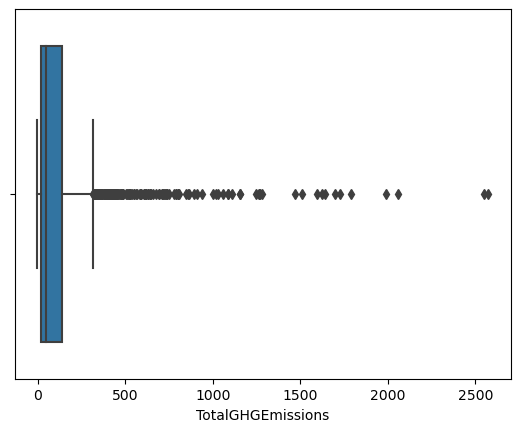

In [52]:
sns.boxplot(data=df, x='TotalGHGEmissions')

In [53]:
df[df["TotalGHGEmissions"] <= 0]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
513,700,Supermarket / Grocery Store,MAGNOLIA / QUEEN ANNE,2008,1,1.0,57176,0,57176,39500.0,31.0,1.284386e+07,0.0,6365315.0,0.0,0.0,5.020
3206,49784,Small- and Mid-Sized Office,CENTRAL,2013,1,6.0,52000,0,52000,48159.0,100.0,2.401321e+05,0.0,1478403.0,0.0,-0.8,0.555


In [54]:
df.loc[df["TotalGHGEmissions"] <= 0, "TotalGHGEmissions"] = np.nan
# Liste des colonnes à traiter
columns_to_fill = ["TotalGHGEmissions"]

# Remplir les valeurs manquantes
for col in columns_to_fill:
    df = replace_nan_by_mediane(df, "PrimaryPropertyType", col)

### SteamUse(kBtu)

<Axes: xlabel='SteamUse(kBtu)'>

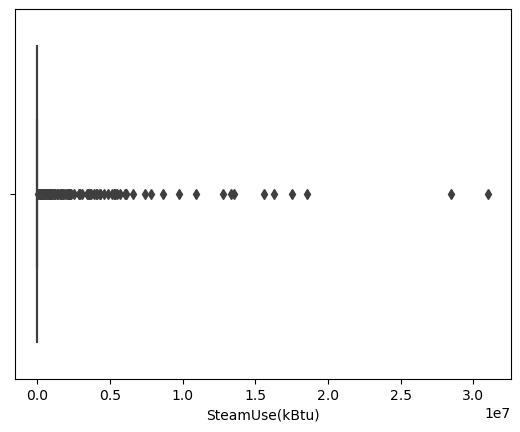

In [55]:
sns.boxplot(data=df, x='SteamUse(kBtu)')

In [56]:
len(df[df['SteamUse(kBtu)'] >= 1.5e+07])

6

In [57]:
df = df[df['SteamUse(kBtu)'] <= 1.5e+07]

In [58]:
df.describe()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1518.000000,1518.000000,1518.000000,1518.000000,1.518000e+03,1518.000000,1.518000e+03,1.518000e+03,976.000000,1.518000e+03,1.518000e+03,1.518000e+03,1.518000e+03,1518.000000,1518.000000
mean,16580.555336,1961.579051,1.155468,4.127800,1.071571e+05,13400.700922,9.216251e+04,8.422977e+04,63.784836,6.503492e+06,1.813953e+05,4.661652e+06,1.492510e+06,125.877737,1.586723
std,13737.615790,32.884629,1.138211,6.311994,1.697369e+05,42712.021352,1.448039e+05,1.307009e+05,28.789685,9.739132e+06,1.014439e+06,7.929358e+06,3.137859e+06,209.095200,2.159991
min,1.000000,1900.000000,1.000000,1.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,1.000000,5.811420e+04,0.000000e+00,6.138000e+03,0.000000e+00,0.400000,0.010000
25%,610.250000,1930.000000,1.000000,1.000000,2.943725e+04,0.000000,2.776700e+04,2.492425e+04,44.000000,1.322536e+06,0.000000e+00,7.278888e+05,0.000000e+00,20.207500,0.350000
50%,21210.000000,1965.000000,1.000000,2.000000,4.890700e+04,0.000000,4.550000e+04,4.143850e+04,71.000000,2.788274e+06,0.000000e+00,1.668195e+06,4.725610e+05,49.265000,0.875000
75%,24619.000000,1988.000000,1.000000,4.000000,1.038575e+05,0.000000,9.154000e+04,8.841550e+04,88.250000,7.149921e+06,0.000000e+00,4.951488e+06,1.470013e+06,135.665000,1.930000
max,50226.000000,2015.000000,27.000000,99.000000,1.605578e+06,512608.000000,1.592914e+06,1.585960e+06,100.000000,6.650284e+07,1.355622e+07,6.382214e+07,3.468533e+07,2055.820000,25.710000


## Analyse univariée et bivariée

In [59]:
df.head()

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
0,1,Hotel,DOWNTOWN,1927,1,12.0,88434,0,88434,88434.0,60.0,7456910.0,2003882.00,3946027.0,1276453.0,249.98,2.83
1,2,Hotel,DOWNTOWN,1996,1,11.0,103566,15064,88502,83880.0,61.0,8664479.0,0.00,3242851.0,5145082.0,295.86,2.86
3,5,Hotel,DOWNTOWN,1926,1,10.0,61320,0,61320,61320.0,56.0,6946800.5,2214446.25,2768924.0,1811213.0,286.43,4.67
4,8,Hotel,DOWNTOWN,1980,1,18.0,175580,62000,113580,123445.0,75.0,14656503.0,0.00,5368607.0,8803998.0,505.01,2.88
5,9,Other,DOWNTOWN,1999,1,2.0,97288,37198,60090,88830.0,NaN,12581712.0,0.00,7371434.0,4715182.0,301.81,3.10


### Colonne PrimaryPropertyType

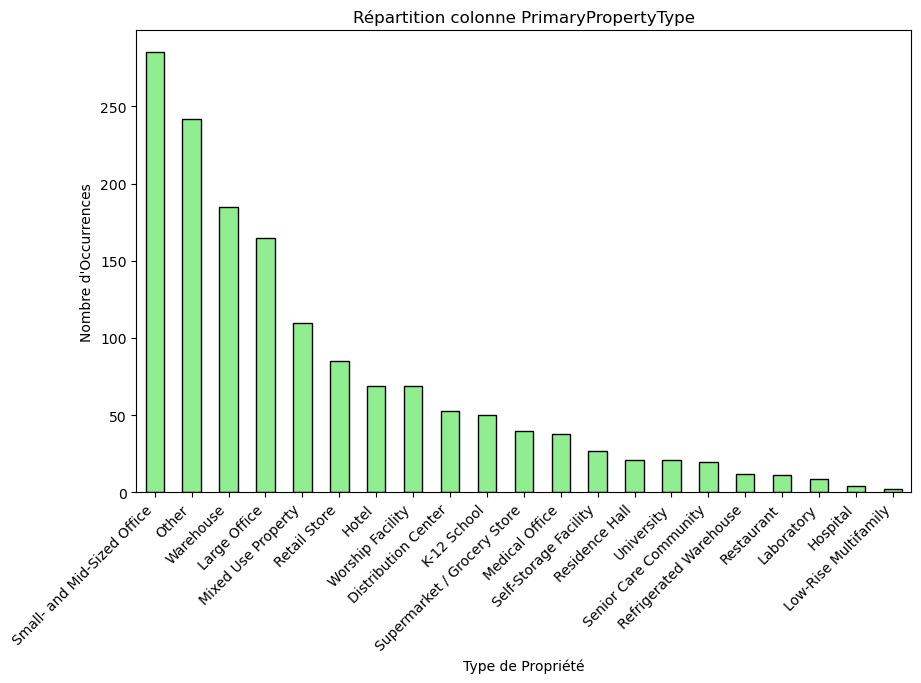

In [60]:
showRepartitionVarCategorielle('PrimaryPropertyType')

### Colonne Neighborhood

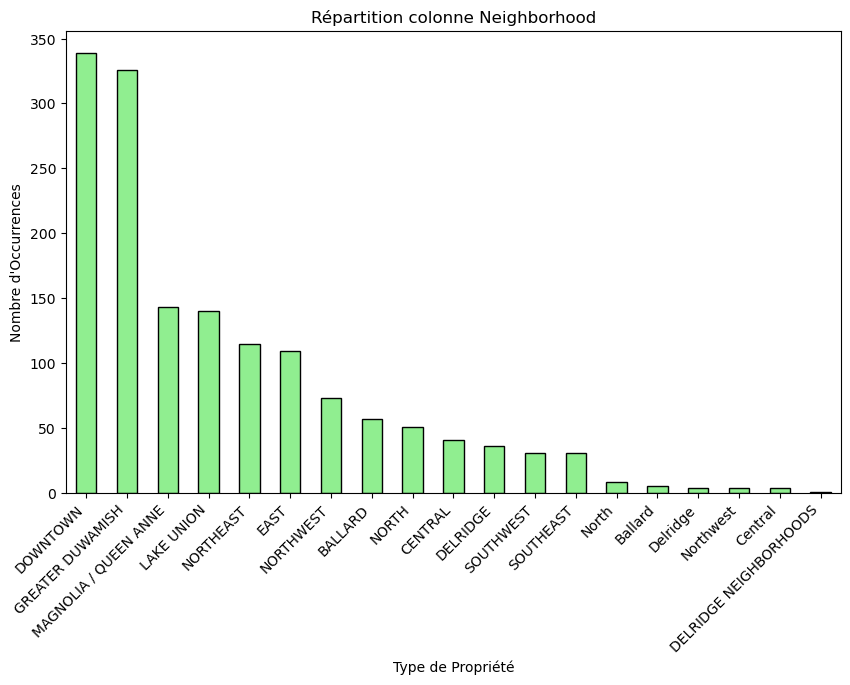

In [61]:
showRepartitionVarCategorielle('Neighborhood')

In [62]:
# Normalisation des noms des quartiers en majuscules
df['Neighborhood'] = df['Neighborhood'].str.upper()

# Suppression des espaces inutiles autour des noms
df['Neighborhood'] = df['Neighborhood'].str.strip()

# Vérification des valeurs uniques après nettoyage
print(df['Neighborhood'].unique())

['DOWNTOWN' 'NORTHEAST' 'EAST' 'LAKE UNION' 'GREATER DUWAMISH'
 'MAGNOLIA / QUEEN ANNE' 'BALLARD' 'NORTHWEST' 'CENTRAL' 'SOUTHWEST'
 'SOUTHEAST' 'DELRIDGE' 'NORTH' 'DELRIDGE NEIGHBORHOODS']


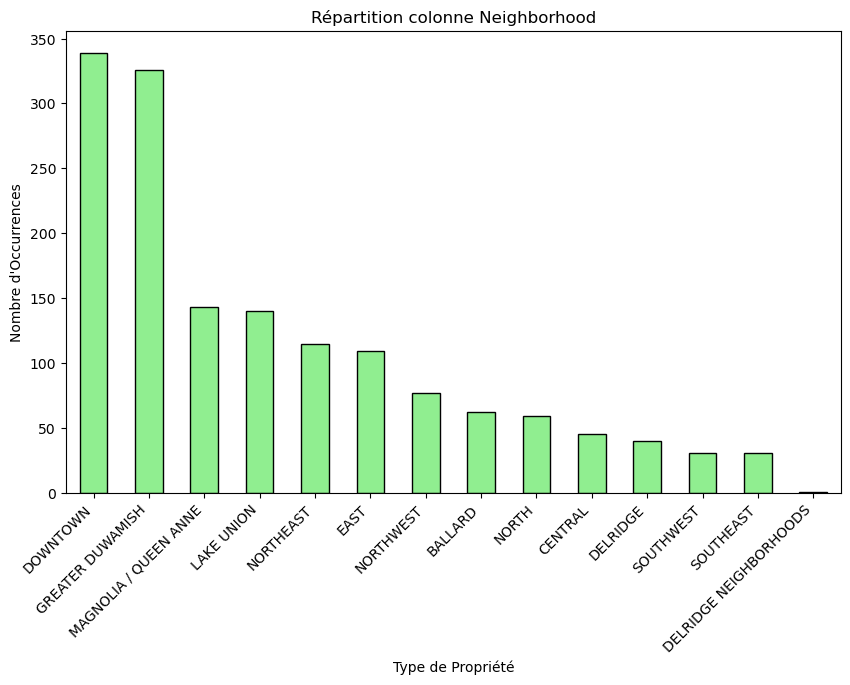

In [63]:
showRepartitionVarCategorielle('Neighborhood')

### PropertyGFAParking

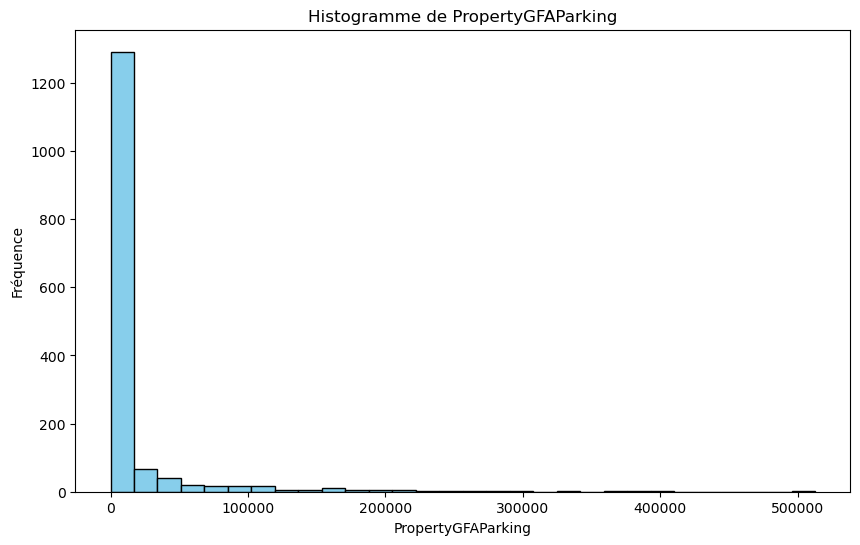

In [64]:
import matplotlib.pyplot as plt

# Visualisation : Histogramme
plt.figure(figsize=(10, 6))
plt.hist(df['PropertyGFAParking'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogramme de PropertyGFAParking')
plt.xlabel('PropertyGFAParking')
plt.ylabel('Fréquence')
plt.show()

## Distribution des variables cibles

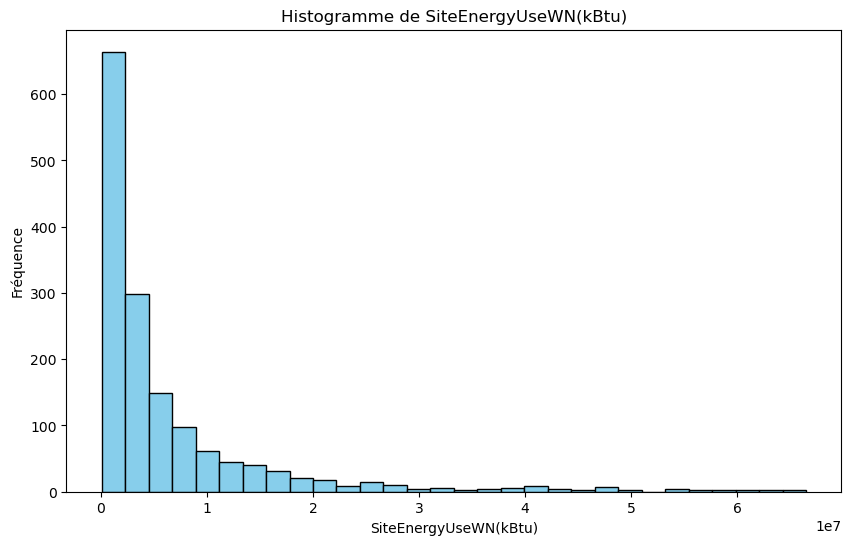

In [65]:
import matplotlib.pyplot as plt

# Visualisation : Histogramme
plt.figure(figsize=(10, 6))
plt.hist(df["SiteEnergyUseWN(kBtu)"], bins=30, color='skyblue', edgecolor='black')
plt.title("Histogramme de SiteEnergyUseWN(kBtu)")
plt.xlabel("SiteEnergyUseWN(kBtu)")
plt.ylabel('Fréquence')
plt.show()

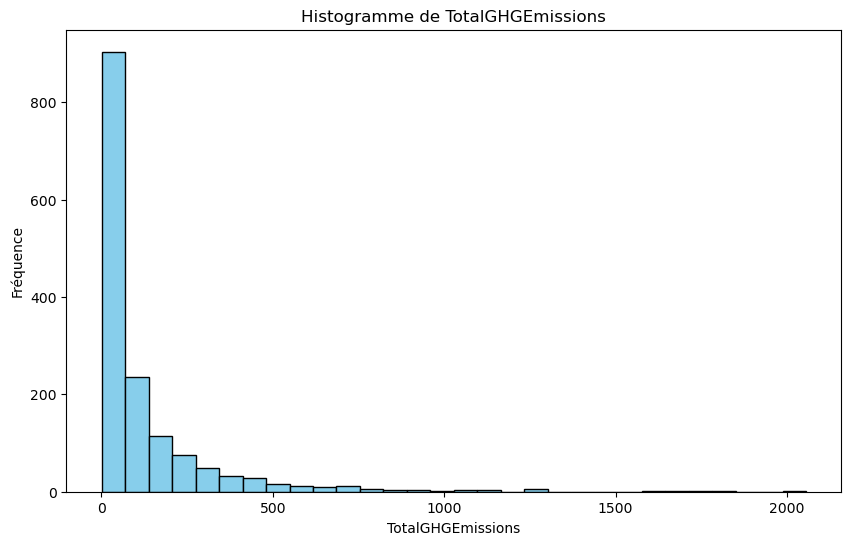

In [66]:
import matplotlib.pyplot as plt

# Visualisation : Histogramme
plt.figure(figsize=(10, 6))
plt.hist(df["TotalGHGEmissions"], bins=30, color='skyblue', edgecolor='black')
plt.title("Histogramme de TotalGHGEmissions")
plt.xlabel("TotalGHGEmissions")
plt.ylabel('Fréquence')
plt.show()

## Vérification de l'impact de la transformation logarithmique

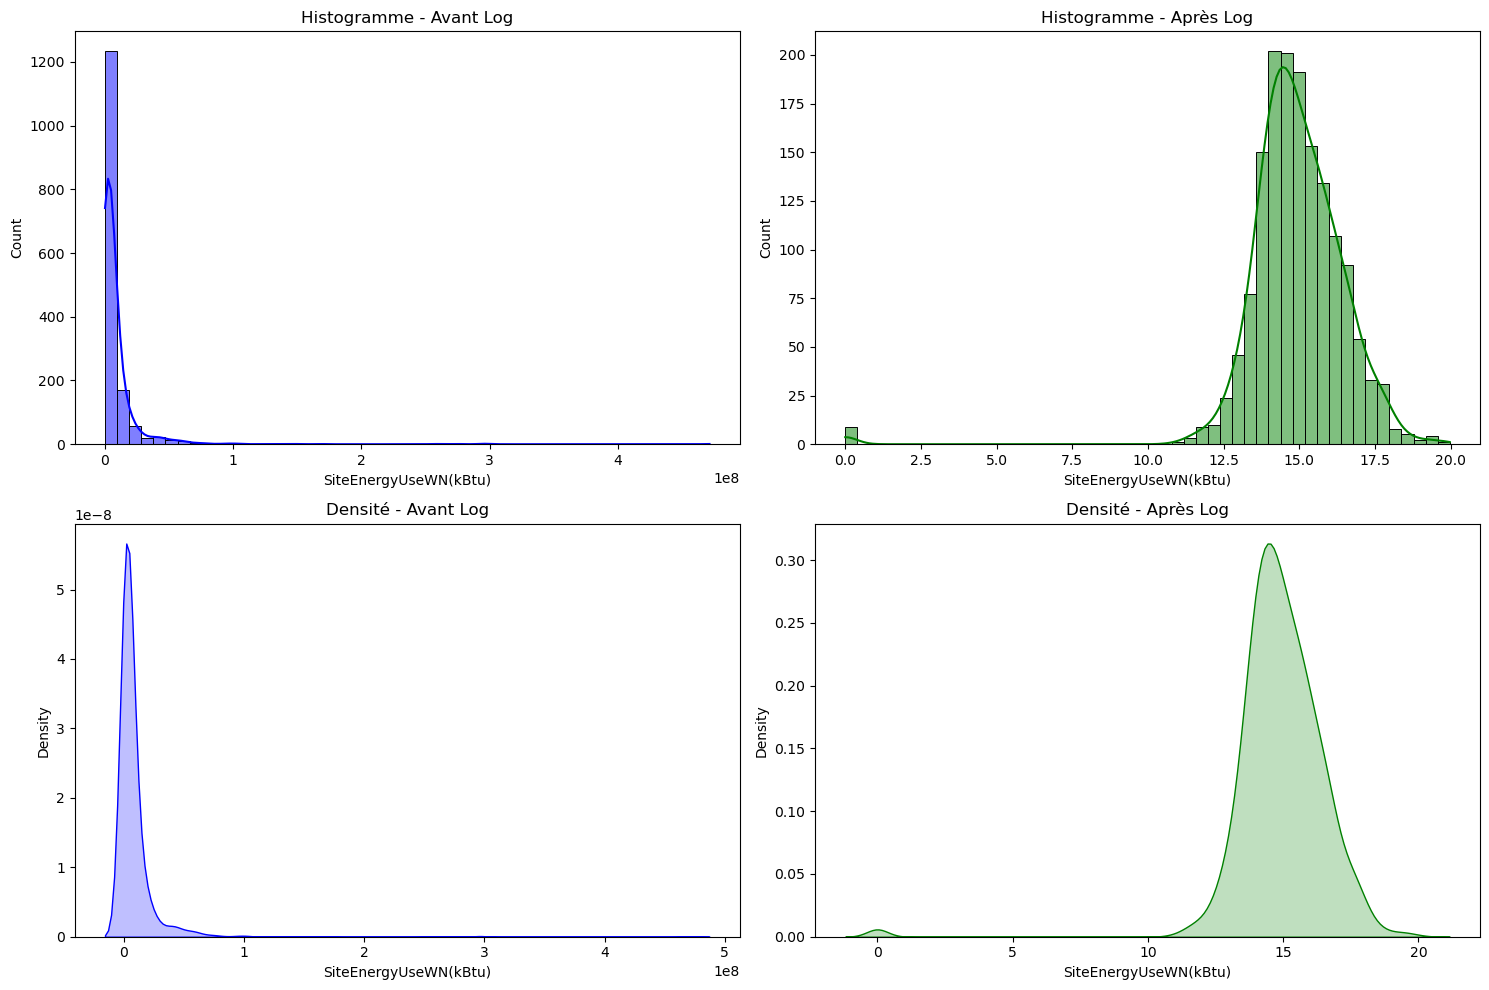

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraction de la variable
y = df1['SiteEnergyUseWN(kBtu)']

# Transformation logarithmique
y_log = np.log1p(y)

# Création des sous-graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme avant transformation
sns.histplot(y, bins=50, kde=True, ax=axes[0, 0], color="blue")
axes[0, 0].set_title("Histogramme - Avant Log")

# Histogramme après transformation
sns.histplot(y_log, bins=50, kde=True, ax=axes[0, 1], color="green")
axes[0, 1].set_title("Histogramme - Après Log")

# Densité avant transformation
sns.kdeplot(y, ax=axes[1, 0], color="blue", fill=True)
axes[1, 0].set_title("Densité - Avant Log")

# Densité après transformation
sns.kdeplot(y_log, ax=axes[1, 1], color="green", fill=True)
axes[1, 1].set_title("Densité - Après Log")


# Ajustement de l'affichage
plt.tight_layout()
plt.show()

## Visualisation des relations

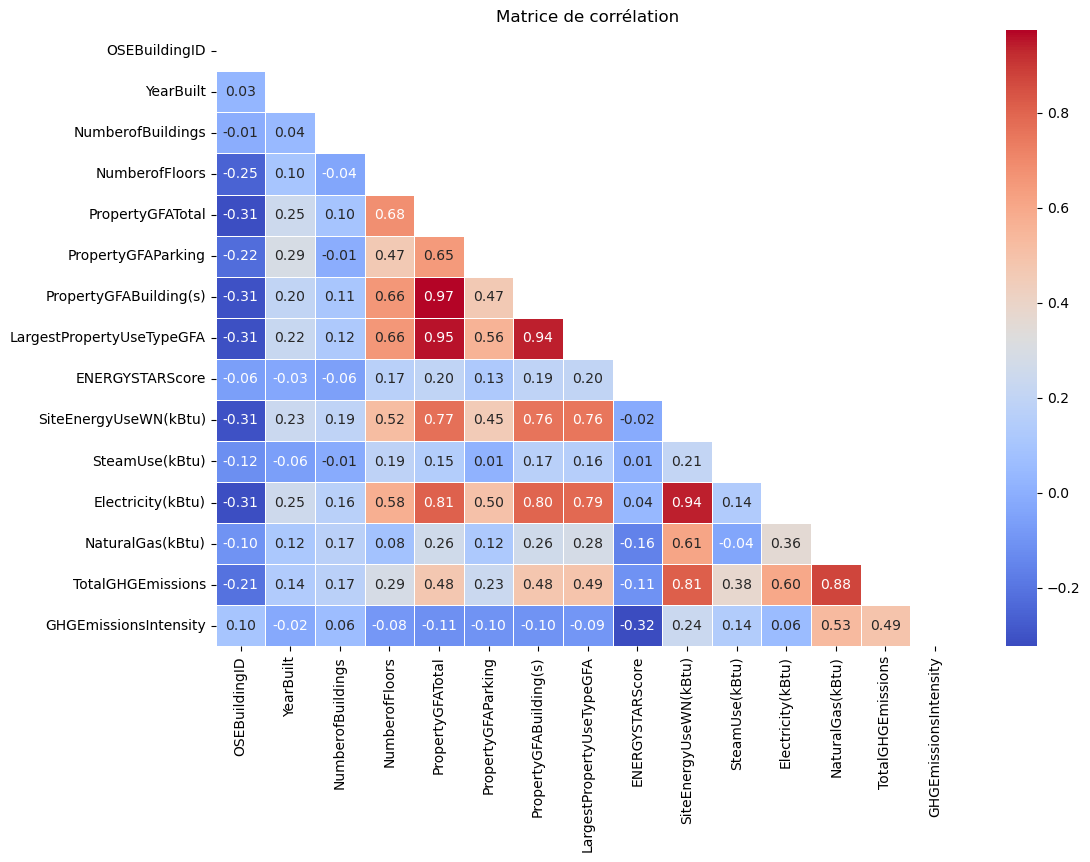

In [68]:
correlation()

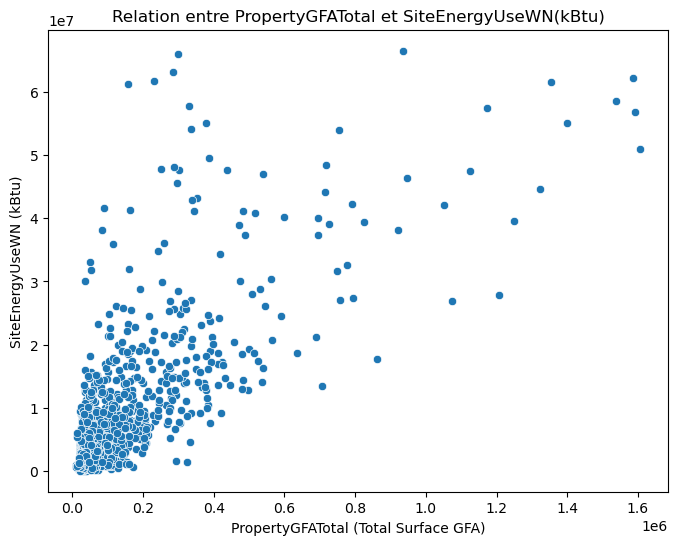

In [69]:
# 1. Relation entre PropertyGFATotal et SiteEnergyUseWN(kBtu)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["PropertyGFATotal"], y=df["SiteEnergyUseWN(kBtu)"])
plt.title("Relation entre PropertyGFATotal et SiteEnergyUseWN(kBtu)")
plt.xlabel("PropertyGFATotal (Total Surface GFA)")
plt.ylabel("SiteEnergyUseWN (kBtu)")
plt.show()

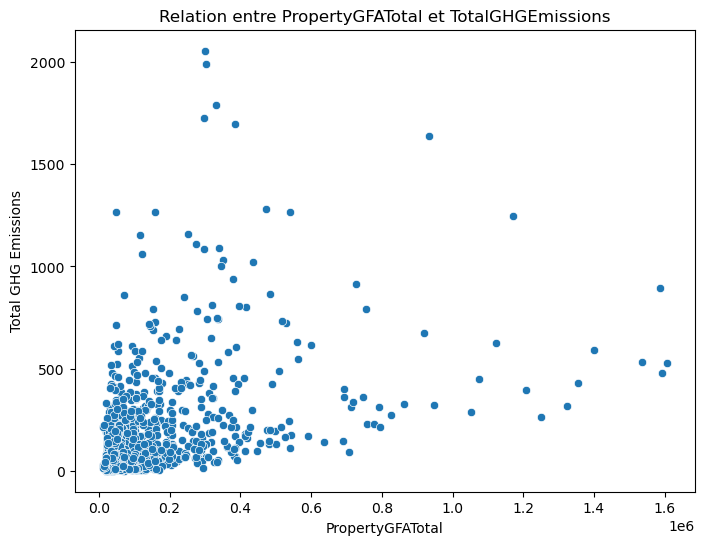

In [70]:
# 2. Relation entre TotalGHGEmissions et SiteEnergyUseWN(kBtu)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["PropertyGFATotal"], y=df["TotalGHGEmissions"])
plt.title("Relation entre PropertyGFATotal et TotalGHGEmissions")
plt.xlabel("PropertyGFATotal")
plt.ylabel("Total GHG Emissions")
plt.show()

In [71]:
df.shape

(1518, 17)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1518 entries, 0 to 3375
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   OSEBuildingID              1518 non-null   int64  
 1   PrimaryPropertyType        1518 non-null   object 
 2   Neighborhood               1518 non-null   object 
 3   YearBuilt                  1518 non-null   int64  
 4   NumberofBuildings          1518 non-null   int64  
 5   NumberofFloors             1518 non-null   float64
 6   PropertyGFATotal           1518 non-null   int64  
 7   PropertyGFAParking         1518 non-null   int64  
 8   PropertyGFABuilding(s)     1518 non-null   int64  
 9   LargestPropertyUseTypeGFA  1518 non-null   float64
 10  ENERGYSTARScore            976 non-null    float64
 11  SiteEnergyUseWN(kBtu)      1518 non-null   float64
 12  SteamUse(kBtu)             1518 non-null   float64
 13  Electricity(kBtu)          1518 non-null   float

In [73]:
# Enregistrer le DataFrame dans un fichier CSV
df.to_csv('AED_building.csv', index=False)